# Step 1: Environment Setup


In [31]:
!pip install kagglehub plotly streamlit -q

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os
os.makedirs('images', exist_ok=True)
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Step 2: Data Acquisition

In [32]:
# Download the Olist Brazilian E-Commerce dataset directly from Kaggle using kagglehub
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Path to dataset files:", path)

# List all files inside the downloaded dataset folder to confirm successful download
print("\nFiles in dataset:")
print(os.listdir(path))

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce

Files in dataset:
['olist_customers_dataset.csv', 'olist_sellers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_items_dataset.csv', 'olist_products_dataset.csv', 'olist_geolocation_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_payments_dataset.csv']


In [33]:
#  Load all 8 CSV files into separate pandas DataFrames
# Print shape of each to verify data loaded correctly and check row/column counts

orders = pd.read_csv(f"{path}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
customers = pd.read_csv(f"{path}/olist_customers_dataset.csv")
payments = pd.read_csv(f"{path}/olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")
products = pd.read_csv(f"{path}/olist_products_dataset.csv")
sellers = pd.read_csv(f"{path}/olist_sellers_dataset.csv")
category_translation = pd.read_csv(f"{path}/product_category_name_translation.csv")

# Quick shape check for all
for name, df in [("orders", orders), ("order_items", order_items), ("customers", customers),
                  ("payments", payments), ("reviews", reviews), ("products", products),
                  ("sellers", sellers), ("category_translation", category_translation)]:
    print(f"{name}: {df.shape}")

orders: (99441, 8)
order_items: (112650, 7)
customers: (99441, 5)
payments: (103886, 5)
reviews: (99224, 7)
products: (32951, 9)
sellers: (3095, 4)
category_translation: (71, 2)


# Step 3: Data Understanding

In [34]:
# Inspect structure (dtypes, non-null counts, sample rows) of every individual dataset
# This helps identify data types, missing values, and column meanings before merging

datasets = {
    "orders": orders, "order_items": order_items, "customers": customers,
    "payments": payments, "reviews": reviews, "products": products,
    "sellers": sellers, "category_translation": category_translation
}

for name, df in datasets.items():
    print(f"\n{'='*50}\n{name.upper()}\n{'='*50}")
    print(df.info())
    print(df.head(2))



ORDERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   

  order_status order_purchase

In [35]:
# Merge all 8 tables into a single master DataFrame using their relational keys
# Using left joins from 'orders' as the base to preserve all orders even if related
# records (reviews, payments) are missing — avoids biasing the dataset by dropping data early


df = orders.merge(order_items, on='order_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(payments, on='order_id', how='left')
df = df.merge(reviews, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(sellers, on='seller_id', how='left')
df = df.merge(category_translation, on='product_category_name', how='left')

print("Final merged shape:", df.shape)
df.head()

Final merged shape: (119143, 40)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,auto


In [36]:
# Sanity-check the merge: confirm duplicate order_ids are expected (multi-item orders),
# review overall missing values, and list final columns to plan the cleaning step


print("Duplicate order_ids after merge (expected due to multiple items per order):")
print(df['order_id'].duplicated().sum())

print("\nMissing values per column (top 15):")
print(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nColumn list:")
print(df.columns.tolist())

Duplicate order_ids after merge (expected due to multiple items per order):
19702

Missing values per column (top 15):
review_comment_title             105154
review_comment_message            68898
order_delivered_customer_date      3421
product_category_name_english      2567
product_name_lenght                2542
product_description_lenght         2542
product_category_name              2542
product_photos_qty                 2542
order_delivered_carrier_date       2086
review_id                           997
review_answer_timestamp             997
review_score                        997
review_creation_date                997
product_height_cm                   853
product_length_cm                   853
dtype: int64

Column list:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_dat

# Step 4: Data Cleaning

In [37]:
# Convert all date columns from string/object type to proper datetime format
# Required for calculating delivery times and time-based trends later

date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'review_creation_date',
    'review_answer_timestamp', 'shipping_limit_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(df[date_cols].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
review_creation_date             datetime64[ns]
review_answer_timestamp          datetime64[ns]
shipping_limit_date              datetime64[ns]
dtype: object


In [38]:
# Handle missing values with reasoning instead of dropping rows blindly:
# - Flag missing review comments/delivery dates as informative signals (not noise)
# - Fill missing product category with 'unknown' to retain associated order data

df['has_review_comment'] = df['review_comment_message'].notnull().astype(int)

# 2. order_delivered_customer_date missing: order was never delivered (cancelled/lost)
# Create a flag rather than dropping — this is a real business signal, not noise
df['is_delivered'] = df['order_delivered_customer_date'].notnull().astype(int)

# 3. product info missing (name_lenght, description_lenght, category, photos_qty):
# These 2542 rows are products with incomplete catalog data — likely a data entry gap upstream
# Fill category with 'unknown' rather than dropping, so we don't lose the order/payment/review data tied to them
df['product_category_name_english'] = df['product_category_name_english'].fillna('unknown')

# 4. review_score / review_id missing: order has no review at all
# Keep as NaN for now — we exclude these only when specifically analyzing review scores, not globally

# Check remaining nulls
print(df.isnull().sum().sort_values(ascending=False).head(10))

review_comment_title             105154
review_comment_message            68898
order_delivered_customer_date      3421
product_category_name              2542
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
order_delivered_carrier_date       2086
review_id                           997
review_score                        997
dtype: int64


In [39]:
# Delivery delay: actual delivery vs estimated delivery (negative = early, positive = late)
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

# Time to deliver: purchase to actual delivery
df['delivery_time_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# Time to approve payment
df['approval_time_hours'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 3600

# Extract purchase month/year/day-of-week for time-based trends
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_year'] = df['order_purchase_timestamp'].dt.year
df['purchase_dayofweek'] = df['order_purchase_timestamp'].dt.day_name()

print(df[['delivery_delay_days', 'delivery_time_days', 'approval_time_hours']].describe())

       delivery_delay_days  delivery_time_days  approval_time_hours
count        115722.000000       115722.000000        118966.000000
mean            -12.048392           12.022589            10.581018
std              10.163801            9.454922            25.955995
min            -147.000000            0.000000             0.000000
25%             -17.000000            6.000000             0.215556
50%             -13.000000           10.000000             0.346944
75%              -7.000000           15.000000            15.048611
max             188.000000          209.000000          4509.180556


In [40]:
# Check for negative/impossible values
print("Negative delivery times:", (df['delivery_time_days'] < 0).sum())
print("Negative prices:", (df['price'] < 0).sum())
print("Negative freight:", (df['freight_value'] < 0).sum())

# Check extreme outliers in price (not removing yet — just observing)
print("\nPrice distribution:")
print(df['price'].describe())
print("\nTop 1% price threshold:", df['price'].quantile(0.99))

Negative delivery times: 0
Negative prices: 0
Negative freight: 0

Price distribution:
count    118310.000000
mean        120.646603
std         184.109691
min           0.850000
25%          39.900000
50%          74.900000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

Top 1% price threshold: 895.0


In [41]:
# Full row duplicates (not order_id duplicates — those are expected from multi-item orders)
print("Fully duplicated rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing true duplicates:", df.shape)

Fully duplicated rows: 0
Shape after removing true duplicates: (119143, 48)


## 🎯 Stakeholder Brief

**Persona:** Head of Operations, Olist  
**Business Goal:** Reduce customer dissatisfaction and improve delivery
efficiency without increasing operating cost.

### Questions this dashboard must answer:
1. How is delivery performance trending over time — improving or worsening?
2. Which regions have the worst delivery times, and where should we prioritize
   fulfillment investment?
3. Which product categories generate the most dissatisfaction, and is it
   delivery-related or product-related?
4. What is the relationship between order value, payment behavior, and customer
   satisfaction — are big spenders happier or more demanding?
5. If we fix delivery delay, what's the realistic upside on review scores?

# Step 5 : KPI Design


In [42]:
# Define core business KPIs that Operations leadership would track weekly/monthly
# These are the numbers that go in an executive summary, not exploratory stats

kpi_on_time_rate = (df['delivery_delay_days'] <= 0).mean() * 100
kpi_avg_review_score = df['review_score'].mean()
kpi_avg_delivery_days = df['delivery_time_days'].mean()
kpi_pct_1star = (df['review_score'] == 1).mean() * 100
kpi_avg_delay_late_orders = df[df['delivery_delay_days'] > 0]['delivery_delay_days'].mean()

print(f"📦 On-Time Delivery Rate: {kpi_on_time_rate:.1f}%")
print(f"⭐ Average Review Score: {kpi_avg_review_score:.2f} / 5")
print(f"🚚 Average Delivery Time: {kpi_avg_delivery_days:.1f} days")
print(f"🔴 % of Orders with 1-Star Review: {kpi_pct_1star:.1f}%")
print(f"⏰ Avg Delay (late orders only): {kpi_avg_delay_late_orders:.1f} days late")

📦 On-Time Delivery Rate: 90.8%
⭐ Average Review Score: 4.02 / 5
🚚 Average Delivery Time: 12.0 days
🔴 % of Orders with 1-Star Review: 12.9%
⏰ Avg Delay (late orders only): 10.6 days late


#Step 6: Static Visual Storytelling (Portfolio-Grade Charts)

### Q1: Is delivery performance improving or worsening over time?

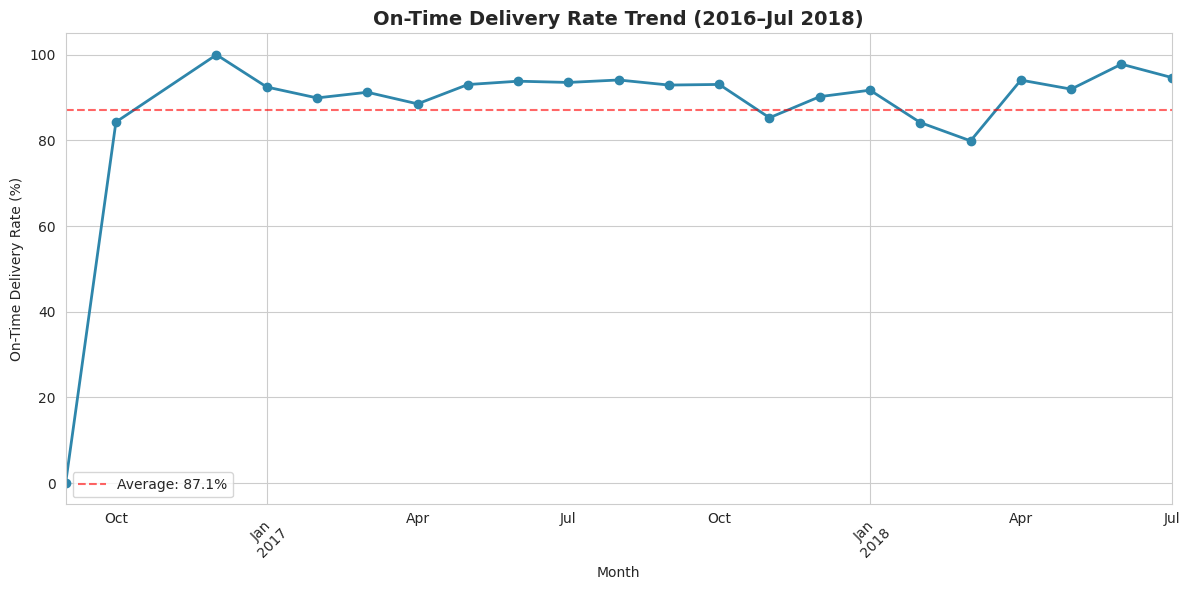

In [44]:
# Q1: Track on-time delivery rate trend month-over-month

monthly_perf = df[df['order_purchase_timestamp'] < '2018-08-01'].groupby(
    df['order_purchase_timestamp'].dt.to_period('M')
).apply(lambda x: (x['delivery_delay_days'] <= 0).mean() * 100)

plt.figure(figsize=(12, 6))
monthly_perf.plot(kind='line', marker='o', color='#2E86AB', linewidth=2)
plt.axhline(monthly_perf.mean(), color='red', linestyle='--', alpha=0.6, label=f'Average: {monthly_perf.mean():.1f}%')
plt.title('On-Time Delivery Rate Trend (2016–Jul 2018)', fontsize=14, fontweight='bold')
plt.ylabel('On-Time Delivery Rate (%)')
plt.xlabel('Month')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/ontime_delivery_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Q2: Which regions have the worst delivery times?

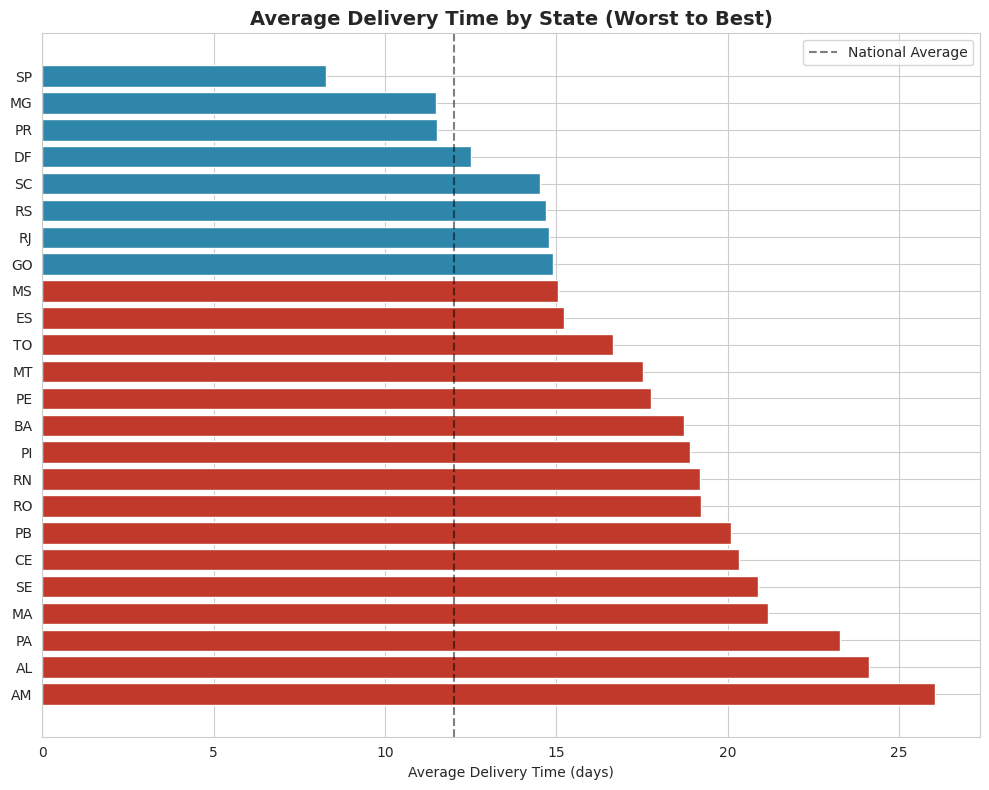

In [46]:
# Q2: Rank states by average delivery time to identify fulfillment investment priorities
# Filtered to states with meaningful order volume (>100) to avoid noisy small-sample states

state_delivery = df.groupby('customer_state').agg(
    avg_delivery_days=('delivery_time_days', 'mean'),
    order_count=('order_id', 'count')
)
state_delivery = state_delivery[state_delivery['order_count'] > 100].sort_values('avg_delivery_days', ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#C0392B' if x > 15 else '#2E86AB' for x in state_delivery['avg_delivery_days']]
plt.barh(state_delivery.index, state_delivery['avg_delivery_days'], color=colors)
plt.title('Average Delivery Time by State (Worst to Best)', fontsize=14, fontweight='bold')
plt.xlabel('Average Delivery Time (days)')
plt.axvline(df['delivery_time_days'].mean(), color='black', linestyle='--', alpha=0.5, label='National Average')
plt.legend()
plt.tight_layout()
plt.savefig('images/state_delivery_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

### Q3: Which categories drive dissatisfaction — delivery-related or product-related?

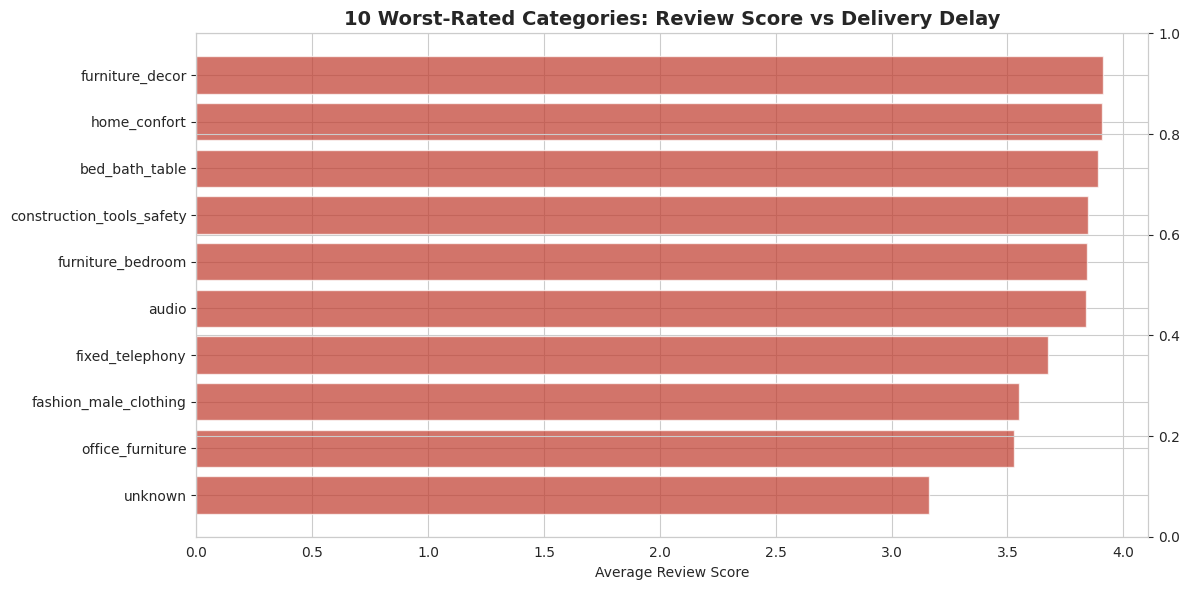

                               avg_review  avg_delay
product_category_name_english                       
unknown                          3.160221 -11.540638
office_furniture                 3.526791 -11.554736
fashion_male_clothing            3.548611 -12.246377
fixed_telephony                  3.672862 -14.614504
audio                            3.840849 -10.224274
furniture_bedroom                3.841270 -14.176471
construction_tools_safety        3.848485 -12.438503
bed_bath_table                   3.890605 -11.721601
home_confort                     3.907563  -9.788584
furniture_decor                  3.912158 -12.448340


In [47]:
# Q3: Compare each category's avg delivery delay AND avg review score side-by-side
# This disentangles WHY a category is rated poorly — is it slow shipping or the product itself?

category_analysis = df.groupby('product_category_name_english').agg(
    avg_review=('review_score', 'mean'),
    avg_delay=('delivery_delay_days', 'mean'),
    order_count=('order_id', 'count')
)
category_analysis = category_analysis[category_analysis['order_count'] > 100].sort_values('avg_review').head(10)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.barh(category_analysis.index, category_analysis['avg_review'], color='#C0392B', alpha=0.7, label='Avg Review Score')
ax1.set_xlabel('Average Review Score')
ax1.set_title('10 Worst-Rated Categories: Review Score vs Delivery Delay', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('images/category_dissatisfaction_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

# Print delay alongside review score to interpret cause (delivery vs product issue)
print(category_analysis[['avg_review', 'avg_delay']])

### Q4: Are big spenders happier or more demanding?

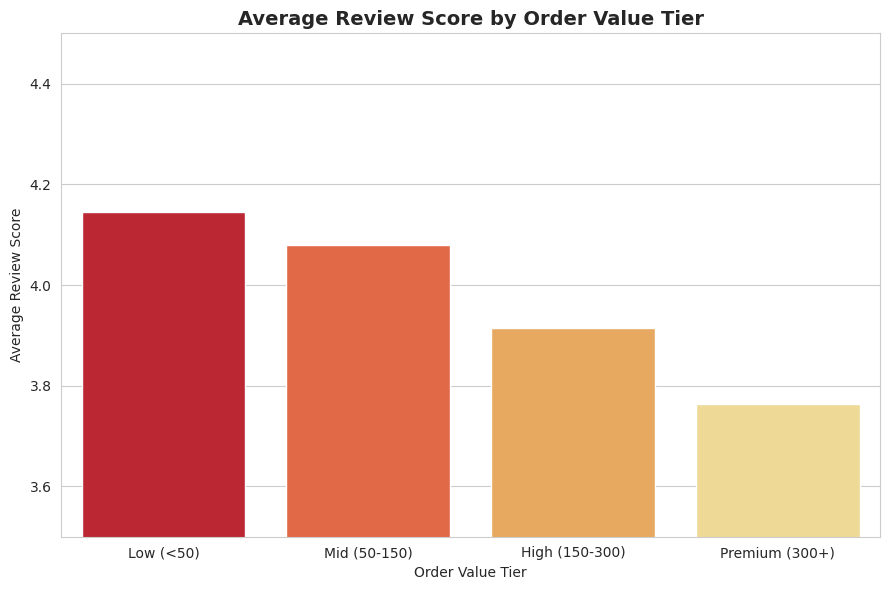

In [48]:
# Q4: Segment orders into value tiers and compare average review score across tiers
# Tests whether higher spend correlates with higher satisfaction or higher expectations

df['value_tier'] = pd.cut(df['payment_value'],
                            bins=[0, 50, 150, 300, np.inf],
                            labels=['Low (<50)', 'Mid (50-150)', 'High (150-300)', 'Premium (300+)'])

tier_review = df.groupby('value_tier')['review_score'].mean()

plt.figure(figsize=(9, 6))
sns.barplot(x=tier_review.index, y=tier_review.values, palette='YlOrRd_r')
plt.title('Average Review Score by Order Value Tier', fontsize=14, fontweight='bold')
plt.ylabel('Average Review Score')
plt.xlabel('Order Value Tier')
plt.ylim(3.5, 4.5)
plt.tight_layout()
plt.savefig('images/value_tier_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

Q5: What's the realistic upside if we fix delivery delay?

Current average review score: 4.016
Projected average review score if all orders were on-time: 4.137
Potential improvement: +0.122 points (3.0% increase)


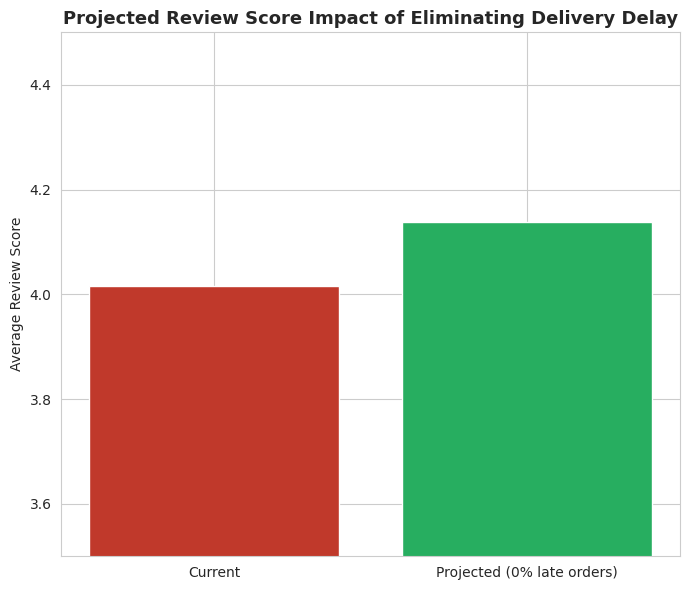

In [49]:
# Q5: Simulate the potential review score improvement if all late orders were made on-time
# This translates the analysis into a business impact projection, not just a correlation

current_avg = df['review_score'].mean()
simulated_df = df.copy()
# If an order was late, assume it would score the average of on-time orders instead
on_time_avg_score = df[df['delivery_delay_days'] <= 0]['review_score'].mean()
simulated_df.loc[simulated_df['delivery_delay_days'] > 0, 'review_score'] = on_time_avg_score
simulated_avg = simulated_df['review_score'].mean()

print(f"Current average review score: {current_avg:.3f}")
print(f"Projected average review score if all orders were on-time: {simulated_avg:.3f}")
print(f"Potential improvement: +{(simulated_avg - current_avg):.3f} points ({((simulated_avg-current_avg)/current_avg)*100:.1f}% increase)")

plt.figure(figsize=(7,6))
plt.bar(['Current', 'Projected (0% late orders)'], [current_avg, simulated_avg], color=['#C0392B', '#27AE60'])
plt.title('Projected Review Score Impact of Eliminating Delivery Delay', fontsize=13, fontweight='bold')
plt.ylabel('Average Review Score')
plt.ylim(3.5, 4.5)
plt.tight_layout()
plt.savefig('images/projected_impact.png', dpi=150, bbox_inches='tight')
plt.show()

#Step 7: Interactive Dashboard (Plotly + Streamlit) — the centerpiece

In [50]:
%%writefile app.py
# Streamlit dashboard for Olist Operations leadership
# Run locally with: streamlit run app.py

import streamlit as st
import pandas as pd
import plotly.express as px
import kagglehub

st.set_page_config(page_title="Olist Operations Dashboard", layout="wide")

# --- Load & prepare data (cached so it doesn't reload on every interaction) ---
@st.cache_data
def load_data():
    path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
    orders = pd.read_csv(f"{path}/olist_orders_dataset.csv")
    order_items = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
    customers = pd.read_csv(f"{path}/olist_customers_dataset.csv")
    payments = pd.read_csv(f"{path}/olist_order_payments_dataset.csv")
    reviews = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")
    products = pd.read_csv(f"{path}/olist_products_dataset.csv")
    sellers = pd.read_csv(f"{path}/olist_sellers_dataset.csv")
    category_translation = pd.read_csv(f"{path}/product_category_name_translation.csv")

    df = orders.merge(order_items, on='order_id', how='left')
    df = df.merge(customers, on='customer_id', how='left')
    df = df.merge(payments, on='order_id', how='left')
    df = df.merge(reviews, on='order_id', how='left')
    df = df.merge(products, on='product_id', how='left')
    df = df.merge(sellers, on='seller_id', how='left')
    df = df.merge(category_translation, on='product_category_name', how='left')

    date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')

    df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
    df['delivery_time_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
    df['product_category_name_english'] = df['product_category_name_english'].fillna('unknown')
    df = df[df['order_purchase_timestamp'] < '2018-08-01']  # exclude incomplete trailing months

    return df

df = load_data()

# --- Header ---
st.title("📦 Olist Operations Dashboard")
st.markdown("**Built for:** Head of Operations | **Purpose:** Track delivery performance and customer satisfaction drivers")

# --- Sidebar Filters ---
st.sidebar.header("Filters")
states = st.sidebar.multiselect("Select States", options=sorted(df['customer_state'].dropna().unique()), default=None)
if states:
    df = df[df['customer_state'].isin(states)]

# --- KPI Row ---
col1, col2, col3, col4 = st.columns(4)
col1.metric("On-Time Delivery Rate", f"{(df['delivery_delay_days'] <= 0).mean()*100:.1f}%")
col2.metric("Avg Review Score", f"{df['review_score'].mean():.2f} / 5")
col3.metric("Avg Delivery Time", f"{df['delivery_time_days'].mean():.1f} days")
col4.metric("1-Star Review Rate", f"{(df['review_score']==1).mean()*100:.1f}%")

st.divider()

# --- Chart 1: Delivery trend over time ---
st.subheader("📈 On-Time Delivery Rate Trend")
monthly_perf = df.groupby(df['order_purchase_timestamp'].dt.to_period('M').astype(str)).apply(
    lambda x: (x['delivery_delay_days'] <= 0).mean() * 100
).reset_index(name='on_time_rate')
fig1 = px.line(monthly_perf, x='order_purchase_timestamp', y='on_time_rate', markers=True,
               labels={'order_purchase_timestamp': 'Month', 'on_time_rate': 'On-Time Rate (%)'})
st.plotly_chart(fig1, use_container_width=True)

# --- Chart 2: Delivery by state ---
st.subheader("🗺️ Delivery Time by State")
state_data = df.groupby('customer_state')['delivery_time_days'].mean().sort_values(ascending=False).reset_index()
fig2 = px.bar(state_data, x='delivery_time_days', y='customer_state', orientation='h',
              labels={'delivery_time_days': 'Avg Delivery Time (days)', 'customer_state': 'State'})
st.plotly_chart(fig2, use_container_width=True)

# --- Chart 3: Category satisfaction ---
st.subheader("📦 Category Review Scores")
cat_data = df.groupby('product_category_name_english').agg(
    avg_review=('review_score', 'mean'), count=('order_id', 'count')
)
cat_data = cat_data[cat_data['count'] > 100].sort_values('avg_review').head(10).reset_index()
fig3 = px.bar(cat_data, x='avg_review', y='product_category_name_english', orientation='h',
              labels={'avg_review': 'Avg Review Score', 'product_category_name_english': 'Category'})
st.plotly_chart(fig3, use_container_width=True)

# --- Chart 4: Delay vs Review correlation ---
st.subheader("⏱️ Delivery Delay Impact on Reviews")
delay_review = df.groupby('review_score')['delivery_delay_days'].mean().reset_index()
fig4 = px.bar(delay_review, x='review_score', y='delivery_delay_days',
              labels={'review_score': 'Review Score', 'delivery_delay_days': 'Avg Delivery Delay (days)'})
st.plotly_chart(fig4, use_container_width=True)

st.divider()
st.caption("Data: Olist Brazilian E-Commerce Dataset (2016–Jul 2018) | Built as part of CodeAlpha Data Analytics Internship")

Overwriting app.py


In [51]:
from google.colab import files
files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>